<a href="https://colab.research.google.com/github/nisha-s10/Pattern-Recognition-Lab-AFI504/blob/main/Experiment%205/Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1 — Import Libraries

In [51]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### Step 2 — Load Dataset

In [52]:
from sklearn.datasets import load_digits

data = load_digits()

X = data.data
y = data.target

# Convert to binary classification
y = (y > 4).astype(int)

print("Dataset shape:", X.shape)
print("Classes:", np.unique(y))

Dataset shape: (1797, 64)
Classes: [0 1]


### Step 3 — Feature Scaling

In [53]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

### Step 4 — Train Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

### Step 5 — Add Bias Term

In [55]:
def add_bias(X):

    ones = np.ones(
        (X.shape[0], 1)
    )

    return np.hstack(
        (ones, X)
    )


X_train = add_bias(X_train)
X_test = add_bias(X_test)

### Step 6 — Sigmoid Function
$$
\sigma(z) =
\frac{1}{1 + e^{-z}}
$$

In [56]:
def sigmoid(z):

    return 1 / (
        1 + np.exp(-z)
    )

### Step 7 — Initialize Parameters

In [57]:
n_features = X_train.shape[1]

weights = np.zeros(
    n_features
)

learning_rate = 0.01

iterations = 1000

### Step 8 — Gradient Descent Training

In [58]:
loss_history = []

for i in range(iterations):

    z = np.dot(
        X_train,
        weights
    )

    predictions = sigmoid(z)

    error = predictions - y_train

    gradient = np.dot(
        X_train.T,
        error
    ) / len(y_train)

    weights = weights - (
        learning_rate * gradient
    )

    loss = -np.mean(
        y_train * np.log(predictions + 1e-9)
        +
        (1 - y_train)
        * np.log(1 - predictions + 1e-9)
    )

    loss_history.append(loss)

### Step 9 — Plot Loss Curve

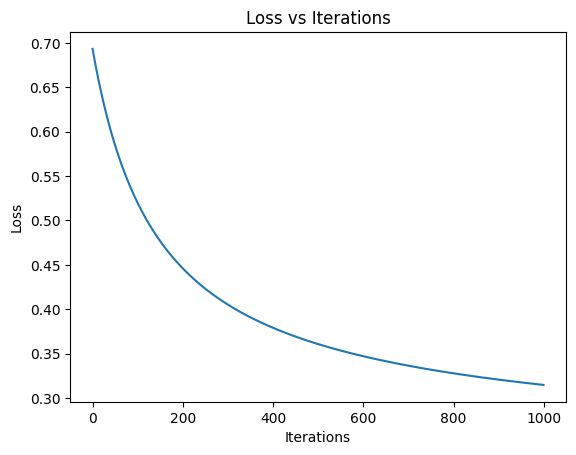

In [59]:
plt.figure()

plt.plot(loss_history)

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.title("Loss vs Iterations")

plt.show()

### Step 10 — Prediction Function

In [60]:
def predict(X):

    z = np.dot(
        X,
        weights
    )

    probabilities = sigmoid(z)

    return (
        probabilities >= 0.5
    ).astype(int)

### Step 11 — Make Predictions

In [61]:
y_pred = predict(X_test)

### Step 12 — Confusion Matrix

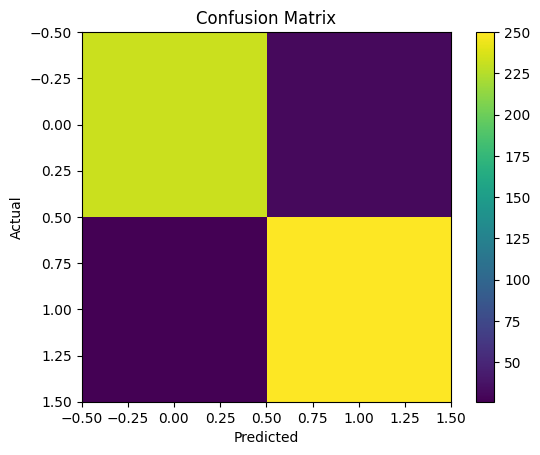

In [62]:
TP = np.sum(
    (y_pred == 1)
    & (y_test == 1)
)

FP = np.sum(
    (y_pred == 1)
    & (y_test == 0)
)

TN = np.sum(
    (y_pred == 0)
    & (y_test == 0)
)

FN = np.sum(
    (y_pred == 0)
    & (y_test == 1)
)

cm = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure()

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

### Step 13 — Accuracy

In [63]:
accuracy = (
    TP + TN
) / (
    TP + TN + FP + FN
)

print("Accuracy:", accuracy)

Accuracy: 0.8925925925925926


### Step 14 — ROC Curve

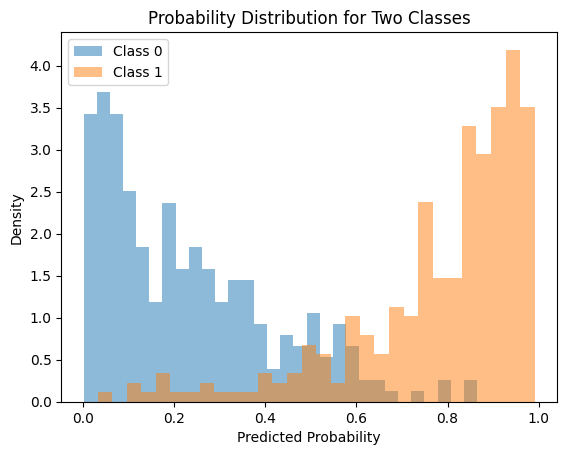

In [64]:
probabilities = sigmoid(
    np.dot(
        X_test,
        weights
    )
)

plt.figure()

plt.hist(
    probabilities[y_test == 0],
    bins=30,
    alpha=0.5,
    density=True,
    label="Class 0"
)

plt.hist(
    probabilities[y_test == 1],
    bins=30,
    alpha=0.5,
    density=True,
    label="Class 1"
)

plt.xlabel("Predicted Probability")

plt.ylabel("Density")

plt.title("Probability Distribution for Two Classes")

plt.legend()

plt.show()

thresholds = np.linspace(
    0,
    1,
    100
)

TPR = []
FPR = []

for t in thresholds:

    preds = (
        probabilities >= t
    ).astype(int)

    TP = np.sum(
        (preds == 1)
        & (y_test == 1)
    )

    FP = np.sum(
        (preds == 1)
        & (y_test == 0)
    )

    TN = np.sum(
        (preds == 0)
        & (y_test == 0)
    )

    FN = np.sum(
        (preds == 0)
        & (y_test == 1)
    )

    tpr = TP / (TP + FN)

    fpr = FP / (FP + TN)

    TPR.append(tpr)
    FPR.append(fpr)

### Accuracy vs Threshold Plot

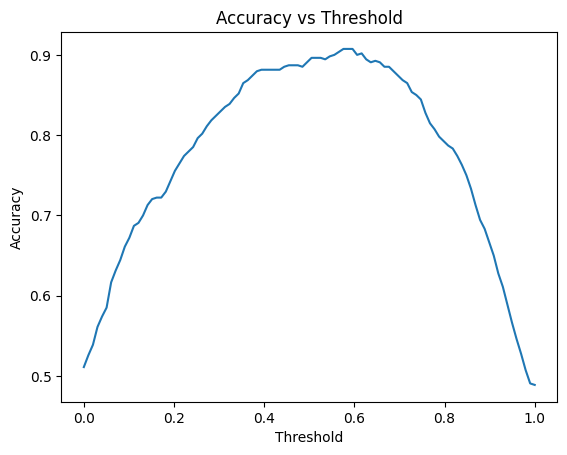

In [65]:
accuracies = []

for t in thresholds:

    preds = (probabilities >= t).astype(int)

    acc = np.mean(preds == y_test)

    accuracies.append(acc)

plt.figure()

plt.plot(thresholds, accuracies)

plt.xlabel("Threshold")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Threshold")

plt.show()

### Step 15 — Compute AUC

In [66]:
TPR = np.array(TPR)
FPR = np.array(FPR)

sorted_idx = np.argsort(FPR)

FPR_sorted = FPR[sorted_idx]
TPR_sorted = TPR[sorted_idx]

auc = np.trapezoid(
    TPR_sorted,
    FPR_sorted
)

print("AUC:", auc)

AUC: 0.9586352657004831


### Step 16 — Plot ROC Curve

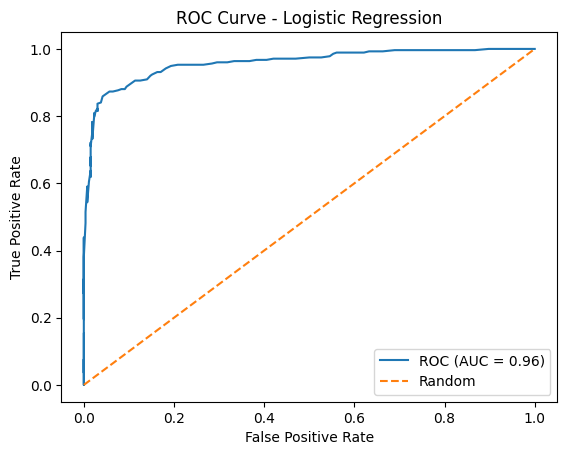

In [67]:
plt.figure()

plt.plot(
    FPR_sorted,
    TPR_sorted,
    label=f"ROC (AUC = {auc:.2f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()